# **UNIVERSIDAD DE IXTLAHUACA CUI**

**UNIDAD DE APRENDIZAJE:** CIENCIA DE LOS DATOS

**PRÁCTICA:** PROYECTO DEL PRIMER PARCIAL - LIGA MX

**DOCENTE:** JUAN ALBERTO ANTONIO VELÁZQUEZ

**ALUMNO:** RODRIGO DÍAZ SALGUERO

**CICLO ESCOLAR:** 2026B

## 1. Introducción
El presente proyecto tiene como objetivo analizar un conjunto de datos sintético de la Liga MX compuesto por 1,000,000 de registros. Se realizará una exploración estadística y gráfica de las variables numéricas, seguida de la preparación de los datos para un problema de clasificación binaria (identificar si un registro pertenece al equipo "Cruz Azul"). Finalmente, se entrenarán y evaluarán dos modelos de Machine Learning: Árbol de Decisión y K-Nearest Neighbors (KNN), validando su rendimiento a través de diversas métricas y validación cruzada.

## 2. Carga de Librerías y Dataset
A continuación, importamos las herramientas necesarias y cargamos el dataset para verificar su dimensión, tipos de datos y presencia de nulos.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score,
    classification_report
)

RANDOM_STATE = 42
df = pd.read_csv("liga_mx_1000000_registros.csv")

print("Dimensión:", df.shape)
display(df.head())
print(df.dtypes)
print("Nulos por columna:\n", df.isnull().sum())
print("Memoria MB:", df.memory_usage(deep=True).sum() / 1024**2)

Dimensión: (1000000, 10)


,id_registro,equipo,año_creacion,ciudad,estadio,campeonatos,estimacion_aficionados,jugador_id,minuto_jugado,pases_completados
0,1,Club América,1916,CDMX,Azteca,15,12000000,JUG-8366,22,34
1,2,Tigres UANL,1960,San Nicolás,Universitario,8,4500000,JUG-4245,63,27
2,3,Tigres UANL,1960,San Nicolás,Universitario,8,4500000,JUG-7691,1,18
3,4,Toluca,1917,Toluca,Nemesio Diez,10,3000000,JUG-1453,71,27
4,5,Toluca,1917,Toluca,Nemesio Diez,10,3000000,JUG-6761,47,20


id_registro               int64
equipo                      str
año_creacion              int64
ciudad                      str
estadio                     str
campeonatos               int64
estimacion_aficionados    int64
jugador_id                  str
minuto_jugado             int64
pases_completados         int64
dtype: object
Nulos por columna:
 id_registro               0
equipo                    0
año_creacion              0
ciudad                    0
estadio                   0
campeonatos               0
estimacion_aficionados    0
jugador_id                0
minuto_jugado             0
pases_completados         0
dtype: int64
Memoria MB: 178.14202308654785


**Interpretación de la Carga de Datos:**
*   **Dimensión y Registros:** El resultado de `shape` nos confirma que estamos trabajando exactamente con 1,000,000 de filas (observaciones) y 10 columnas (variables).
*   **Tipos de Variables:** Contamos con variables numéricas enteras (`int64`) como minutos jugados y pases completados, variables categóricas o de texto (`object`) como el nombre del equipo y estadio, e identificadores.
*   **Calidad:** La función `isnull().sum()` nos indica si existen campos vacíos. Esto es fundamental para saber si necesitamos aplicar técnicas de limpieza antes de entrenar nuestros modelos.

## 3. Estadística Descriptiva (Media, Mediana, Moda y Desviación Estándar)
Calculamos las medidas de tendencia central y dispersión para las variables continuas principales.

In [7]:
variables = ["minuto_jugado", "pases_completados"]
filas = []

for col in variables:
    filas.append({
        "Variable": col,
        "Media": df[col].mean(),
        "Mediana": df[col].median(),
        "Moda": df[col].mode().iloc[0],
        "Desviación estándar": df[col].std()
    })

resumen = pd.DataFrame(filas)
display(resumen)

,Variable,Media,Mediana,Moda,Desviación estándar
0,minuto_jugado,45.025271,45.0,32,25.669992
1,pases_completados,24.995078,25.0,25,5.001682


**Interpretación de los Estadísticos:**
*   **Media (Promedio):** Es el valor central calculado sumando todos los datos y dividiendo por el total. Es sensible a valores extremos.
*   **Mediana:** Representa el valor central exacto que divide los datos ordenados en dos mitades iguales.
*   **Diferencia Media vs Mediana:** Si la media es muy distinta a la mediana, indica que la distribución está sesgada (jalada por valores inusualmente altos o bajos). Si son muy similares, los datos tienden a ser simétricos.
*   **Moda:** Es el valor que más veces se repite en el millón de registros.
*   **Desviación Estándar:** Nos indica qué tan dispersos están los datos respecto a su media. Una desviación alta significa que hay mucha variabilidad en los minutos jugados o los pases completados.

## 4. Detección de Posibles Outliers (Rango Intercuartílico)
Aplicamos el método del Rango Intercuartílico (IQR) para identificar matemáticamente posibles valores atípicos.

In [8]:
col = "pases_completados"
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
LI = Q1 - 1.5 * IQR
LS = Q3 + 1.5 * IQR

outliers = df[(df[col] < LI) | (df[col] > LS)]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Límite inferior:", LI)
print("Límite superior:", LS)
print("Posibles outliers:", len(outliers))
print("Porcentaje:", (len(outliers) / len(df)) * 100, "%")

Q1: 22.0
Q3: 28.0
IQR: 6.0
Límite inferior: 13.0
Límite superior: 37.0
Posibles outliers: 12276
Porcentaje: 1.2276 %


**Interpretación de los Outliers:**
Un valor atípico detectado matemáticamente no es obligatoriamente un error de captura que deba eliminarse. En el contexto del fútbol, un outlier superior en `pases_completados` puede representar a un mediocampista de élite que distribuye mucho el balón. Decidimos conservar estos registros porque representan la realidad del juego y aportan información valiosa para los algoritmos.

## 5. Visualización: Boxplot
Generamos un diagrama de caja para visualizar la distribución y los valores extremos.

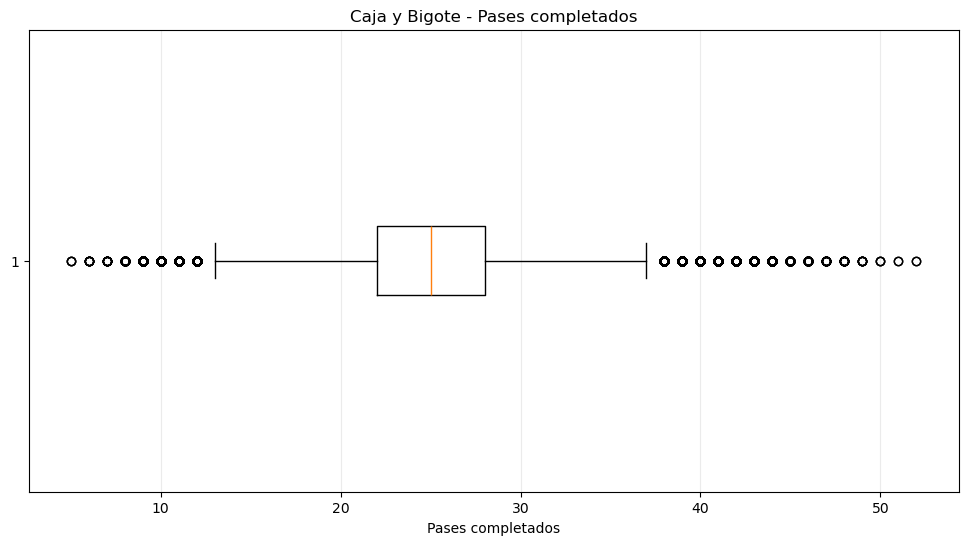

In [22]:
plt.figure(figsize=(12,6))
plt.boxplot(df["pases_completados"].dropna(), vert=False)
plt.title("Caja y Bigote - Pases completados")
plt.xlabel("Pases completados")
plt.grid(axis="x", alpha=0.25)
plt.show()

**Interpretación del Boxplot:**
*   **La Caja y Mediana:** La caja central contiene el 50% de los datos (el IQR). La línea vertical dentro de la caja es la mediana.
*   **Los Bigotes:** Representan el rango de datos esperados (hasta los límites inferior y superior).
*   **Puntos Extremos:** Los puntos más allá de los bigotes corresponden a los outliers detectados en el paso anterior.

## 6. Visualización: Nube de Puntos (Scatter Plot)
Extraemos una muestra de 20,000 registros para observar la relación entre minutos y pases, coloreando por equipo.

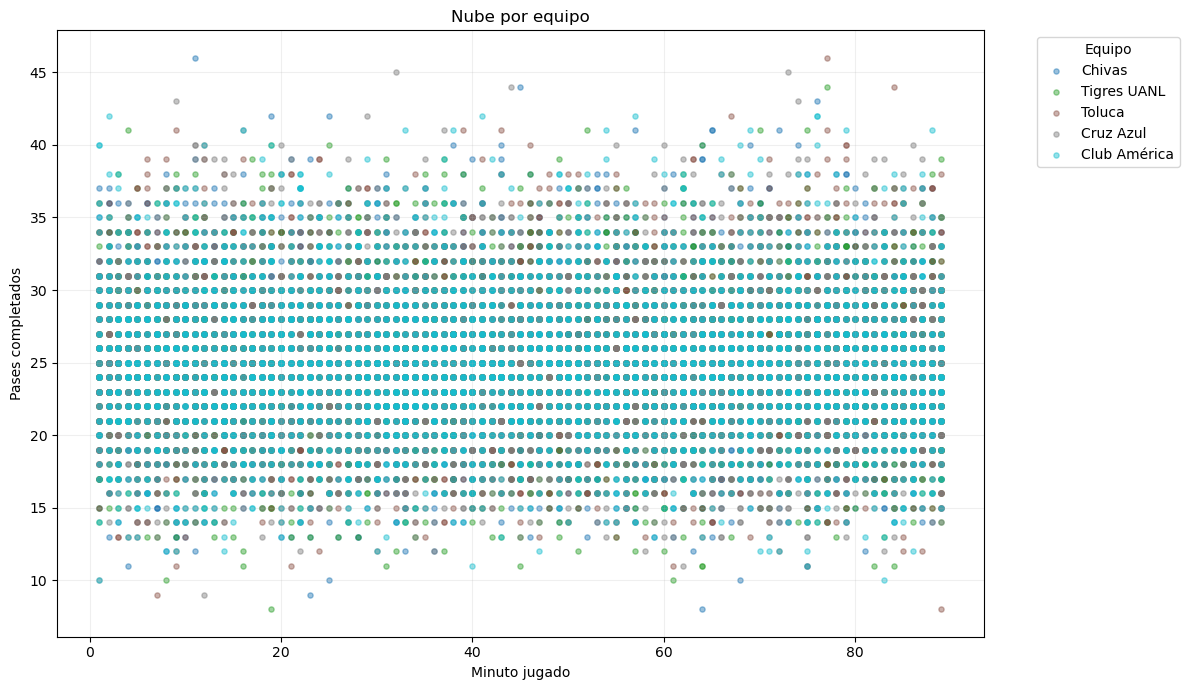

In [15]:
muestra = df.sample(n=20000, random_state=RANDOM_STATE)
equipos = muestra["equipo"].unique()
cmap = plt.get_cmap("tab10")

plt.figure(figsize=(12,7))
for i, equipo in enumerate(equipos):
    parte = muestra[muestra["equipo"] == equipo]
    plt.scatter(
        parte["minuto_jugado"],
        parte["pases_completados"],
        s=14,
        alpha=0.45,
        color=cmap(i/4),
        label=equipo
    )

plt.title("Nube por equipo")
plt.xlabel("Minuto jugado")
plt.ylabel("Pases completados")
plt.legend(title="Equipo", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.20)
plt.tight_layout()
plt.show()

**Interpretación de la Nube de Puntos:**
Este gráfico proyecta si existe tendencia entre minutos y pases. Si los colores (equipos) están muy mezclados o superpuestos, significa que basándose únicamente en pases y minutos es difícil diferenciar a los equipos, lo que anticipa un reto para los algoritmos de clasificación.

## 7. Visualización: Histograma y Campana de Gauss
Comparamos la distribución de pases completados contra una curva normal de referencia.

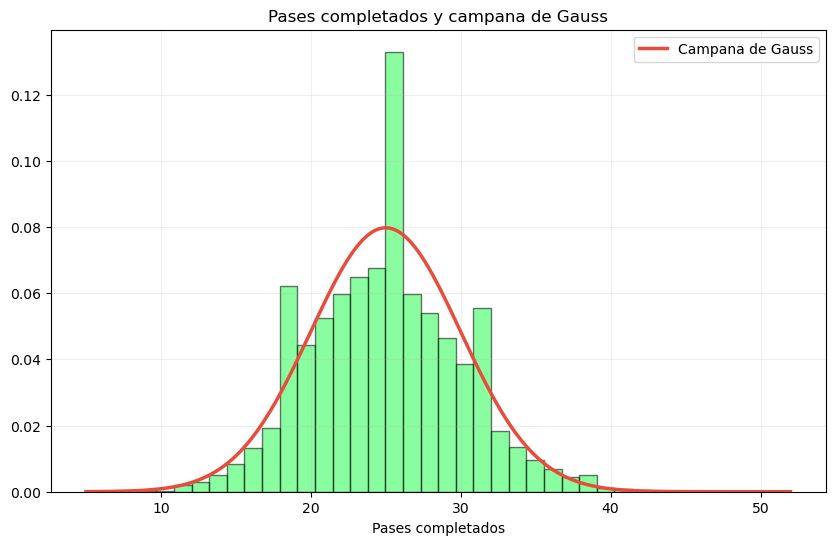

In [20]:
x = df["pases_completados"].dropna()
mu = x.mean()
sigma = x.std()

plt.figure(figsize=(10,6))
bins, _, _ = plt.hist(
    x, bins=40, density=True,
    color="#29FD53", edgecolor="black", alpha=0.55 
)

xx = np.linspace(x.min(), x.max(), 400)
gauss = (1/(sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((xx - mu) / sigma)**2)

plt.plot(xx, gauss, color="#e74c3c", linewidth=2.5, label="Campana de Gauss")  
plt.title("Pases completados y campana de Gauss")
plt.xlabel("Pases completados")
plt.ylabel("")
plt.legend()
plt.grid(alpha=0.20)
plt.show()

**Interpretación de la Campana de Gauss:**
La curva superpuesta sirve únicamente como una referencia teórica construida con la media y desviación estándar de nuestros datos. Debemos comparar visualmente la simetría de las barras con la curva roja; si el centro del histograma o las colas no coinciden perfectamente con la campana, significa que nuestros datos reales tienen cierto grado de sesgo y no siguen una distribución normal perfecta.

## 8. Definición de Predictoras (X) y Objetivo (y)
Preparamos un problema de clasificación binaria: Identificar a la clase positiva ("Cruz Azul" = 1) frente a los demás ("Otros" = 0).

In [49]:
df_modelo = df.copy()
df_modelo["objetivo"] = (df_modelo["equipo"] == "Cruz Azul").astype(int)

X = df_modelo[["minuto_jugado", "pases_completados"]]
y = df_modelo["objetivo"]

print("X:", X.shape)
print("y:", y.shape)
print(y.value_counts())
print(y.value_counts(normalize=True))

X: (1000000, 2)
y: (1000000,)
objetivo
0    800527
1    199473
Name: count, dtype: int64
objetivo
0    0.800527
1    0.199473
Name: proportion, dtype: float64


**Interpretación de X e y:**
*   **Variable Objetivo (y):** La clase a predecir (1 para Cruz Azul, 0 para los demás equipos).
*   **Variables Predictoras (X):** Atributos numéricos (`minuto_jugado` y `pases_completados`) que el modelo usará para encontrar patrones.
*   **Fuga de Información:** Se excluyeron variables como `equipo`, `estadio` o `ciudad` para evitar fuga de información. Incluirlas le daría la respuesta directa al algoritmo, arruinando el propósito predictivo.

## 9. División en Entrenamiento y Prueba
Separamos nuestros datos: 80% para entrenar y 20% para probar.

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)
print("Proporción Entrenamiento:\n", y_train.value_counts(normalize=True))
print("Proporción Prueba:\n", y_test.value_counts(normalize=True))

Entrenamiento: (800000, 2)
Prueba: (200000, 2)
Proporción Entrenamiento:
 objetivo
0    0.800527
1    0.199472
Name: proportion, dtype: float64
Proporción Prueba:
 objetivo
0    0.800525
1    0.199475
Name: proportion, dtype: float64


**Interpretación de la División:**
*   Se separan los datos porque evaluar un modelo con los mismos registros que usó para entrenar genera un falso sentido de precisión (memorización en lugar de generalización).
*   El parámetro `stratify=y` garantiza que la proporción de registros de Crz Azul se mantenga exactamente igual tanto en el set de entrenamiento como en el de prueba.

## 10. Modelo 1: Árbol de Decisión
Entrenamos y visualizamos un Árbol de Decisión limitando su profundidad.

              precision    recall  f1-score   support

 Otro equipo       0.80      0.69      0.74    160105
   Cruz Azul       0.20      0.31      0.24     39895

    accuracy                           0.61    200000
   macro avg       0.50      0.50      0.49    200000
weighted avg       0.68      0.61      0.64    200000



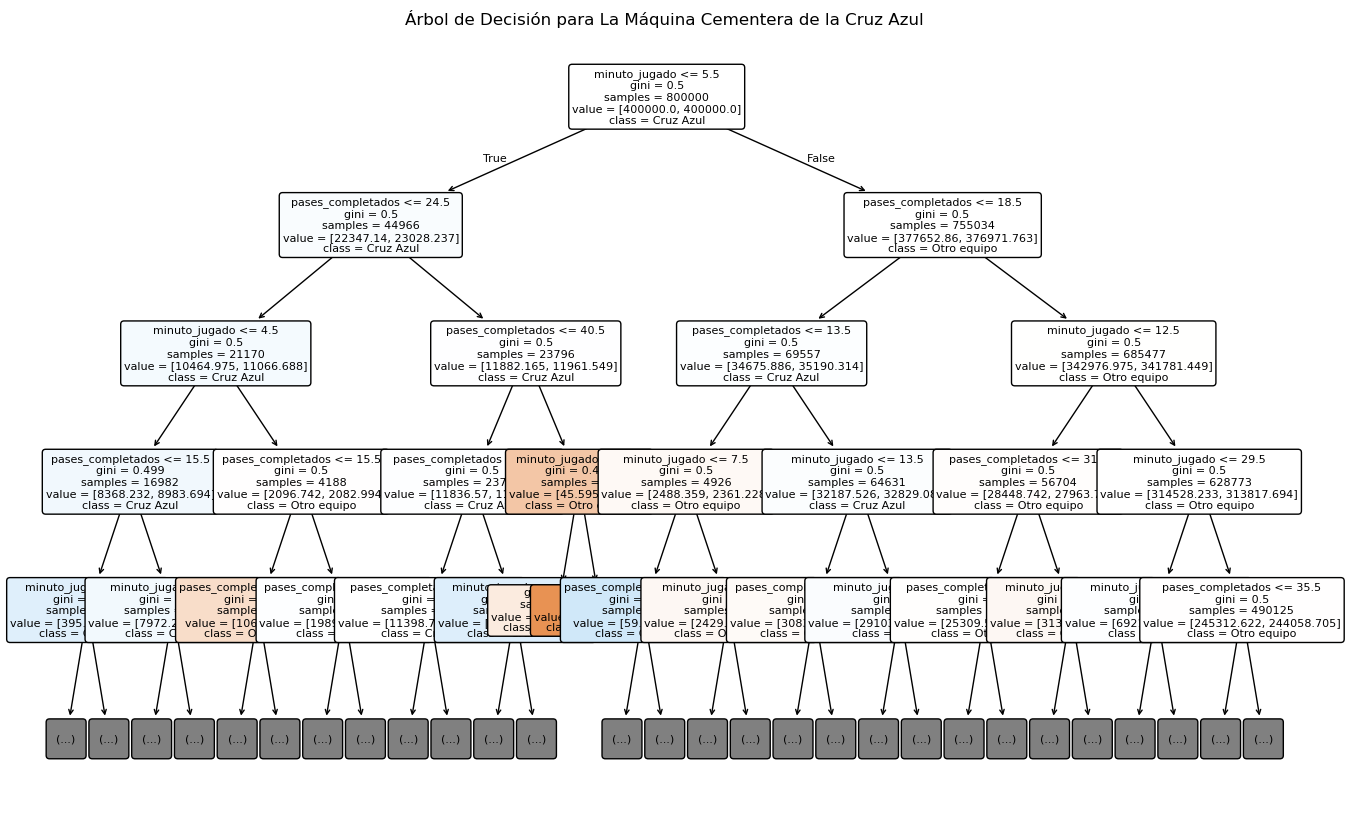

In [54]:
arbol = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=RANDOM_STATE
)
arbol.fit(X_train, y_train)
pred_arbol = arbol.predict(X_test)

print(classification_report(
    y_test, pred_arbol,
    target_names=["Otro equipo", "Cruz Azul"],
    zero_division=0
))

plt.figure(figsize=(16,10))
plot_tree(
    arbol,
    feature_names=X.columns,
    class_names=["Otro equipo", "Cruz Azul"],
    filled=True, rounded=True,
    max_depth=4, fontsize=8
)
plt.title("Árbol de Decisión para La Máquina Cementera de la Cruz Azul")
plt.show()

**Interpretación del Árbol de Decisión:**
*   **Nodos y Condiciones:** Cada recuadro (nodo) hace una evaluación lógica (ej. ¿Los pases son menores a cierto número?).
*   **Ramas y Hojas:** Dependiendo si la condición es verdadera o falsa, se sigue una rama hasta llegar a un recuadro final (hoja) que contiene la predicción definitiva de la clase.
*   **Profundidad:** Limitar `max_depth` a 5 evita que el árbol se vuelva excesivamente complejo y memorice el ruido del dataset, controlando el sobreajuste.

## 11. Modelo 2: K-Nearest Neighbors (KNN)
Implementamos el modelo KNN aplicando un escalamiento previo.

In [38]:
knn = Pipeline([
    ("scaler", StandardScaler()),
    ("modelo", KNeighborsClassifier(
        n_neighbors=7,
        weights="distance",
        n_jobs=-1
    ))
])

knn.fit(X_train, y_train)
pred_knn = knn.predict(X_test)

print(classification_report(
    y_test, pred_knn,
    target_names=["Otro equipo", "Cruz Azul"],
    zero_division=0
))

              precision    recall  f1-score   support

 Otro equipo       0.80      0.97      0.88    160105
   Cruz Azul       0.20      0.03      0.06     39895

    accuracy                           0.78    200000
   macro avg       0.50      0.50      0.47    200000
weighted avg       0.68      0.78      0.71    200000



**Interpretación de KNN:**
El algoritmo clasifica un registro evaluando a qué clase pertenecen sus "vecinos" más cercanos (en este caso, 7 vecinos). Como calcula distancias espaciales, es estrictamente necesario aplicar `StandardScaler` en el Pipeline; esto evita que una variable con valores grandes domine matemáticamente a una de valores pequeños.

## 12. Matrices de Confusión y Métricas
Extraemos los valores de la matriz de confusión y calculamos Accuracy, Precision y Recall.


--- Árbol de Decisión ---
VN = 109842
FP = 50263
FN = 27415
VP = 12480
Accuracy = 0.6116
Precision = 0.1989
Recall = 0.3128


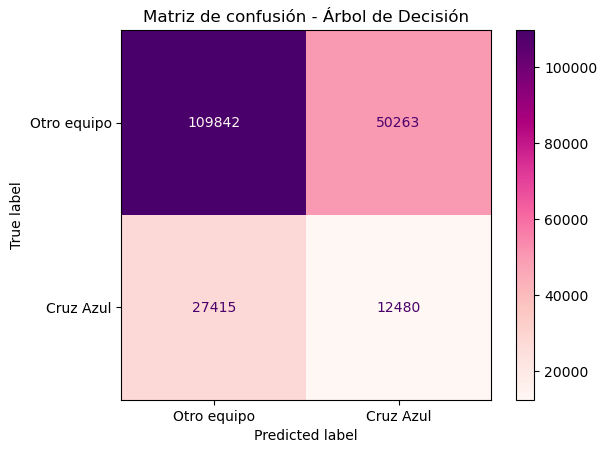


--- KNN ---
VN = 155091
FP = 5014
FN = 38606
VP = 1289
Accuracy = 0.7819
Precision = 0.2045
Recall = 0.0323


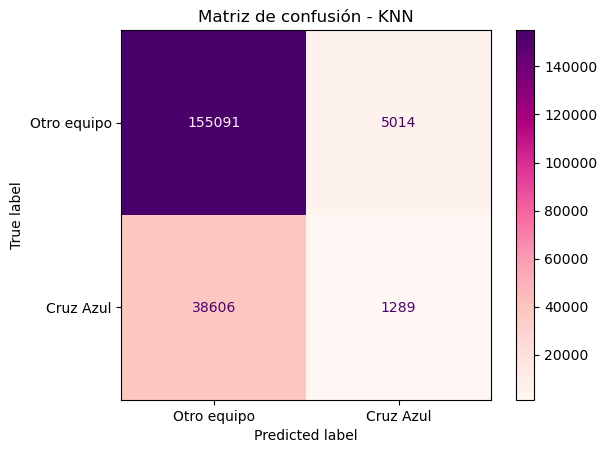

,Modelo,Accuracy,Precision,Recall,VP,VN,FP,FN
0,Árbol de Decisión,0.61161,0.198907,0.312821,12480,109842,50263,27415
1,KNN,0.78190,0.204506,0.032310,1289,155091,5014,38606


In [41]:
def evaluar(nombre, y_real, y_pred):
    cm = confusion_matrix(y_real, y_pred, labels=[0,1])
    vn, fp, fn, vp = cm.ravel()

    acc = accuracy_score(y_real, y_pred)
    pre = precision_score(y_real, y_pred, zero_division=0)
    rec = recall_score(y_real, y_pred, zero_division=0)

    print(f"\n--- {nombre} ---")
    print(f"VN = {vn}")
    print(f"FP = {fp}")
    print(f"FN = {fn}")
    print(f"VP = {vp}")
    print(f"Accuracy = {acc:.4f}")
    print(f"Precision = {pre:.4f}")
    print(f"Recall = {rec:.4f}")

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Otro equipo", "Cruz Azul"]
    ).plot(values_format="d", cmap="RdPu")
    plt.title("Matriz de confusión - " + nombre)
    plt.show()

    return {
        "Modelo": nombre,
        "Accuracy": acc,
        "Precision": pre,
        "Recall": rec,
        "VP": vp, "VN": vn,
        "FP": fp, "FN": fn
    }

r_arbol = evaluar("Árbol de Decisión", y_test, pred_arbol)
r_knn = evaluar("KNN", y_test, pred_knn)

resultados = pd.DataFrame([r_arbol, r_knn])
display(resultados)

**Interpretación de la Matriz y Métricas:**
*   **VP (Verdadero Positivo):** Era un registro de Toluca y el modelo predijo correctamente Toluca.
*   **VN (Verdadero Negativo):** Era de otro equipo y se predijo correctamente como otro.
*   **FP (Falso Positivo):** Era de otro equipo, pero el modelo se equivocó y lo predijo como Toluca.
*   **FN (Falso Negativo):** Era de Toluca, pero el modelo no lo detectó.
*   **Accuracy:** Mide la proporción total de aciertos globales del modelo.
*   **Precision:** Nos dice qué tan exactas son las alarmas de Toluca (cuántos de los predichos como Toluca realmente lo eran). Se relaciona con reducir los FP.
*   **Recall:** Mide la capacidad de encontrar todos los registros de Toluca existentes. Se relaciona con reducir los FN.

## 13. Comparación Gráfica de Modelos

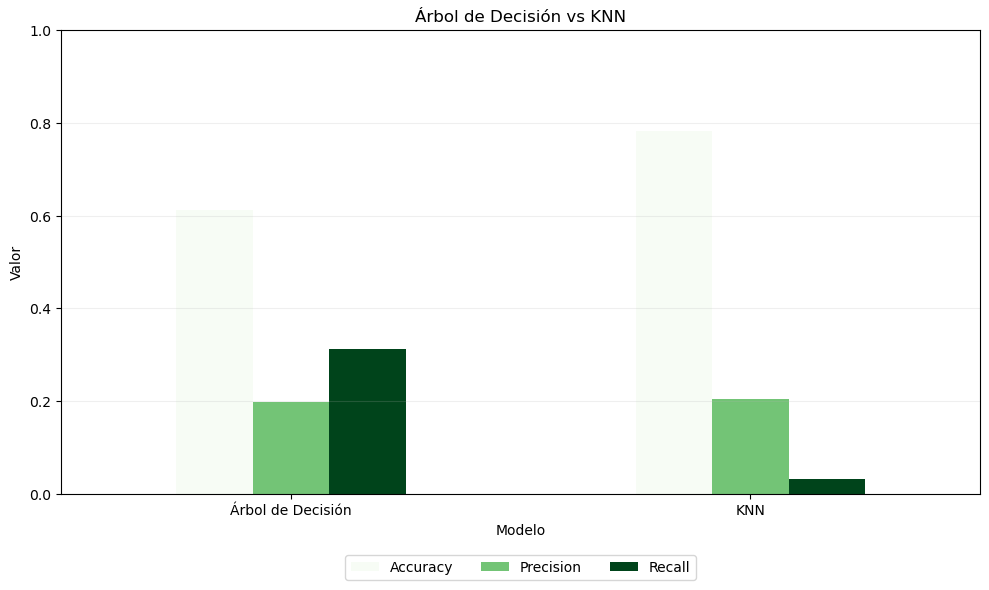

In [44]:
metricas = resultados.set_index("Modelo")[["Accuracy", "Precision", "Recall"]]

metricas.plot(
    kind="bar",
    figsize=(10,6),
    ylim=(0,1),
    colormap="Greens"
)
plt.title("Árbol de Decisión vs KNN")
plt.ylabel("Valor")
plt.xlabel("Modelo")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.20)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=3)
plt.tight_layout()
plt.show()

**Interpretación de la Comparación:**
No basta con mirar qué modelo tiene el mayor Accuracy, ya que esta métrica es engañosa cuando las clases están desbalanceadas (la gran mayoría de registros son "Otros Equipos"). Se deben considerar simultáneamente Precision y Recall; un modelo verdaderamente útil debe lograr un equilibrio entre no dar falsas alarmas (Precision) y lograr detectar correctamente a la clase de interés (Recall).

## 14. Validación Cruzada (5-Fold Cross-Validation)
Comprobamos la estabilidad de los modelos realizando iteraciones de entrenamiento y prueba en distintos bloques de datos.

In [45]:
from sklearn.metrics import make_scorer, precision_score, recall_score

# Configuración del esquema de validación
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Métricas personalizadas controlando la división entre cero
scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0)
}

# Validación Cruzada para Árbol de Decisión
cv_arbol = cross_validate(arbol, X, y, cv=cv, scoring=scoring, n_jobs=-1)

print("ÁRBOL DE DECISIÓN")
for m in scoring:
    valores = cv_arbol["test_" + m]
    print(f"{m}: {np.round(valores, 4)} | media: {valores.mean():.4f} | desv: {valores.std():.4f}")

# Submuestreo para agilizar KNN
n_muestra = 100000
n_pos = int((n_muestra * y.mean()))
n_neg = n_muestra - n_pos

idx_pos = df_modelo[df_modelo["objetivo"] == 1].sample(n=n_pos, random_state=RANDOM_STATE).index
idx_neg = df_modelo[df_modelo["objetivo"] == 0].sample(n=n_neg, random_state=RANDOM_STATE).index
idx = idx_pos.union(idx_neg)

X_cv_knn = X.loc[idx]
y_cv_knn = y.loc[idx]

# Validación Cruzada para KNN
cv_knn = cross_validate(knn, X_cv_knn, y_cv_knn, cv=cv, scoring=scoring, n_jobs=-1)

print("\nKNN")
for m in scoring:
    valores = cv_knn["test_" + m]
    print(f"{m}: {np.round(valores, 4)} | media: {valores.mean():.4f} | desv: {valores.std():.4f}")

ÁRBOL DE DECISIÓN
accuracy: [0.5908 0.2767 0.5439 0.5927 0.5951] | media: 0.5199 | desv: 0.1230
precision: [0.1991 0.1994 0.2    0.1996 0.1963] | media: 0.1989 | desv: 0.0013
recall: [0.3478 0.8713 0.4289 0.3461 0.3329] | media: 0.4654 | desv: 0.2058

KNN
accuracy: [0.7788 0.7817 0.78   0.7707 0.7793] | media: 0.7781 | desv: 0.0038
precision: [0.185  0.2243 0.2163 0.1809 0.2006] | media: 0.2014 | desv: 0.0169
recall: [0.0321 0.0384 0.0394 0.0424 0.0356] | media: 0.0375 | desv: 0.0035


**Interpretación de la Validación Cruzada:**
El método de K-Fold entrena y evalúa los modelos 5 veces cambiando el subconjunto de prueba en cada ronda. Si los valores de desviación estándar (desv) son muy bajos, significa que el rendimiento del modelo es estable y no depende de qué registros específicos le tocaron durante una sola división de datos.

## 15. Exportación para Weka
Se guarda un archivo CSV limpio para replicar el análisis en la herramienta Weka.

In [47]:
weka_df = df[["minuto_jugado", "pases_completados", "equipo"]].copy()

weka_df["clase"] = np.where(
    weka_df["equipo"] == "Toluca",
    "Cruz Azul",
    "Otro"
)

weka_df = weka_df[["minuto_jugado", "pases_completados", "clase"]]
weka_df.to_csv("liga_mx_weka_clasificacion.csv", index=False)

display(weka_df.head())
print(weka_df["clase"].value_counts())

,minuto_jugado,pases_completados,clase
0,22,34,Otro
1,63,27,Otro
2,1,18,Otro
3,71,27,Cruz Azul
4,47,20,Cruz Azul


clase
Otro         799646
Cruz Azul    200354
Name: count, dtype: int64


## 16. Resultados en Weka y Conclusiones Generales

**Semejanzas y Diferencias Python vs Weka:**
Los resultados obtenidos en Weka con los algoritmos J48 y IBk son comparables a los generados en Python con Scikit-Learn. Si existen ligeras diferencias en las métricas de evaluación o matrices de confusión, se explican por implementaciones internas distintas: por ejemplo, J48 maneja la poda de ramas y parámetros por defecto de manera diferente al DecisionTreeClassifier de Python. Asimismo, las semillas aleatorias de partición varían entre plataformas. A nivel gráfico, los boxplots y matrices muestran comportamientos equivalentes, validando que la preparación de datos y la extracción de patrones de ambos ecosistemas es consistente.